# **1. Introduction**

## **Importing libraries**

In [114]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# **2. Dataset Description**

## **2.1 Importing the data from kaggle**

In [115]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "Unemployment_Rate_upto_11_2020.csv"
file_path1 = 'Unemployment in India.csv'

# Load the latest version
#unemployment_rate
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gokulrajkmv/unemployment-in-india",
  file_path,
)

#unemployment_in_india
df1 = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "gokulrajkmv/unemployment-in-india",
  file_path1,
)




/tmp/ipykernel_1703/1473415135.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unemployment-in-india' dataset.


/tmp/ipykernel_1703/1473415135.py:17: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df1 = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unemployment-in-india' dataset.


## **2.2 Dataset Overview**

In [116]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [117]:
df.info()

df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


(267, 9)

In [118]:
df1.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [119]:
df1.info()

df1.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


(768, 7)

# **3. Data Cleaning & Preprocessing**

## **3.1 Removing Missing Values**

In [120]:
df = df.dropna(how="all")
df1 = df1.dropna(how="all")

## **3.2 Removing Duplicate Records**

In [121]:
df = df.drop_duplicates()
df1 = df1.drop_duplicates()

## **3.3 Cleaning Columns**

In [122]:
df.columns = df.columns.str.strip()
df1.columns = df1.columns.str.strip()

df = df.drop(labels="Frequency", axis=1)
df1 = df1.drop(labels="Frequency", axis=1)

dummie = list(df.columns)
dummie[5] = 'Location'
df.columns = dummie

## **3.4 mering the two datasets**

In [123]:
list_to_keep = ['Date', 'Region', 'Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)', 'Estimated Employed']

unemployement_in_india = pd.concat([df1[list_to_keep], df[list_to_keep]], ignore_index=True)

## **3.5 Clean the raws with messing columns & Checking Data Consistency**

In [124]:
df_regions = df['Region'].unique()
df1_regions = df1['Region'].unique()

unemployement_in_india = unemployement_in_india[unemployement_in_india['Region'].isin(df_regions)]

regions = unemployement_in_india['Region'].unique()

print(f'Number of regions in df: {len(df_regions)}')
print(f'Number of regions in df1: {len(df1_regions)}')
print(f'Number of regions in unemployement_in_india: {len(regions)}')

print(f'Number of unique dates in unemployement_in_india: {len(unemployement_in_india['Date'].unique())}')

Number of regions in df: 27
Number of regions in df1: 28
Number of regions in unemployement_in_india: 27
Number of unique dates in unemployement_in_india: 18


In [125]:
expected_dates = set(unemployement_in_india['Date'].unique())

cleaned_regions = []

for region in regions:
    region_dates = set(
        unemployement_in_india.loc[
            unemployement_in_india['Region'] == region,
            'Date'
        ]
    )

    if region_dates == expected_dates:
        cleaned_regions.append(region)

unemployement_in_india = unemployement_in_india[unemployement_in_india['Region'].isin(cleaned_regions)]
regions = unemployement_in_india['Region'].unique()

In [126]:
unemployement_in_india['Date'].unique()

array([' 31-05-2019', ' 30-06-2019', ' 31-07-2019', ' 31-08-2019',
       ' 30-09-2019', ' 31-10-2019', ' 30-11-2019', ' 31-12-2019',
       ' 31-01-2020', ' 29-02-2020', ' 31-03-2020', ' 30-04-2020',
       ' 31-05-2020', ' 30-06-2020', ' 31-07-2020', ' 31-08-2020',
       ' 30-09-2020', ' 31-10-2020'], dtype=object)

## **3.6 Final Clean Dataset**

In [127]:
df.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Location,longitude,latitude
0,Andhra Pradesh,31-01-2020,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,17.43,12988845,36.46,South,15.9129,79.74


In [128]:
df1.head()

,Region,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,5.17,12256762.0,44.68,Rural


In [129]:
unemployement_in_india.head()

,Date,Region,Estimated Unemployment Rate (%),Estimated Labour Participation Rate (%),Estimated Employed
0,31-05-2019,Andhra Pradesh,3.65,43.24,11999139.0
1,30-06-2019,Andhra Pradesh,3.05,42.05,11755881.0
2,31-07-2019,Andhra Pradesh,3.75,43.50,12086707.0
3,31-08-2019,Andhra Pradesh,3.32,43.97,12285693.0
4,30-09-2019,Andhra Pradesh,5.17,44.68,12256762.0


# **4. Exploratory Data Analysis (EDA)**

## **4.1 Unemployment Trends Across Indian States**

25


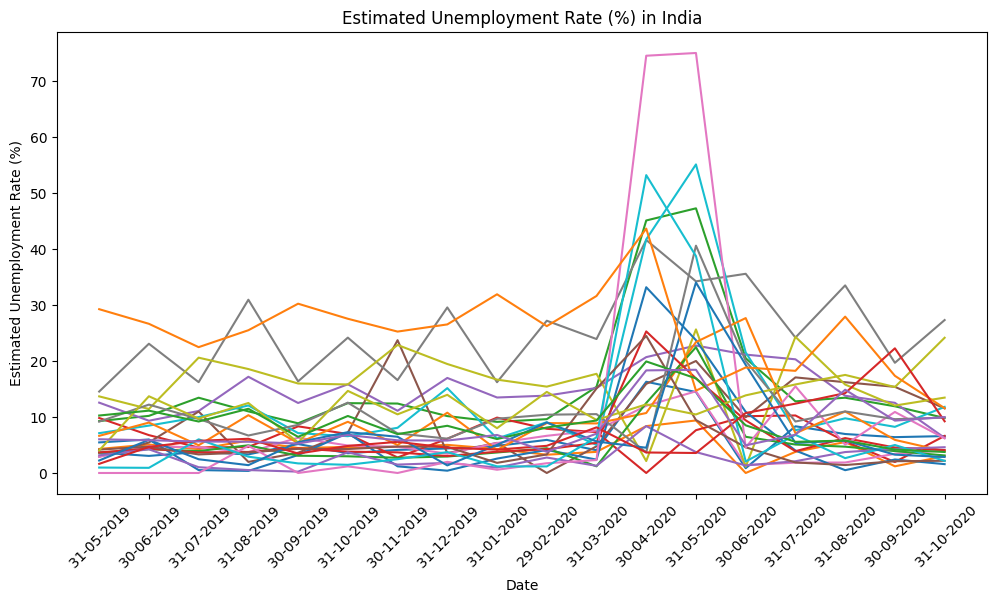

In [130]:
plt.figure(figsize=(12, 6))

print(len(regions))

total_dates = unemployement_in_india['Date'].unique()
i=0

for region in regions:
  x = []
  y = []
  region_data = unemployement_in_india[unemployement_in_india['Region']==region]

  for date in total_dates:
    x.append(region_data.loc[region_data['Date'] == date, 'Date'].iloc[0])
    y.append(region_data.loc[region_data['Date'] ==date, 'Estimated Unemployment Rate (%)'].iloc[0])
  plt.plot(x, y, label=region)

plt.xticks(rotation=45)

plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in India')

plt.show()

### **Observations**

bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla

### **Interpretation**

bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla bla

## **4.2 National Average Unemployment Over Time**

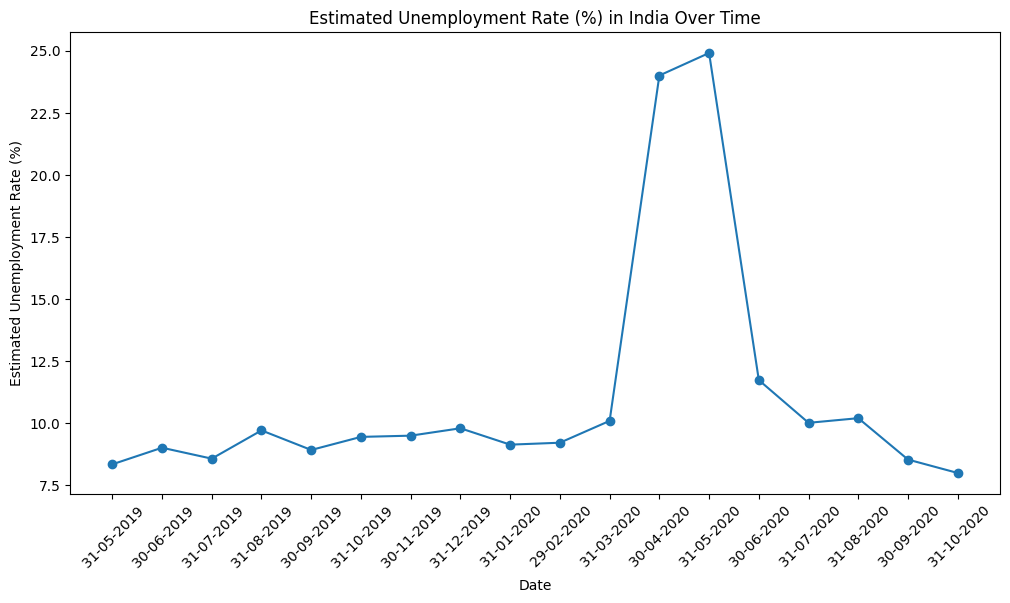

In [131]:
plt.figure(figsize=(12, 6))

df1_mean = pd.DataFrame()
est = []

for date in total_dates:
  y = unemployement_in_india[unemployement_in_india['Date']==date]
  df1_mean['Date'] = total_dates
  est.append(y['Estimated Unemployment Rate (%)'].mean())

df1_mean['Estimated Unemployment Rate (%)'] = est
plt.plot(df1_mean['Date'], df1_mean['Estimated Unemployment Rate (%)'], '-o')

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in India Over Time')

plt.show()

### **Observations**

*   From May 2019 to March 2020, the estimated unemployment rate remained relatively steady, fluctuating within a narrow range between roughly 8% and 10%.

*   There is a massive, sharp spike that begins after March 31, 2020, where the rate shoots up from around 10% to nearly 24% by April 30, 2020.

*  The rate peaks on May 31, 2020, reaching its highest point on the chart at approximately 25%.

*   Following the peak, there is a steep decline between May and June 2020, and by October 31, 2020, the rate returns to a low of about 8%.

### **Interpretation**

As shown in the graph above, the **Estimated Unemployment Rate** in India remained relatively stable until **31 March 2020**. Around this time, the COVID-19 pandemic began to have a significant global impact. In **March 2020**, the **World Health Organization (WHO)** officially declared the COVID-19 outbreak a pandemic. Following this declaration, the unemployment rate in India increased noticeably, suggesting a strong relationship between the pandemic and rising unemployment.

**Reference:** https://www.nm.org/healthbeat/medical-advances/new-therapies-and-drug-trials/covid-19-pandemic-timeline


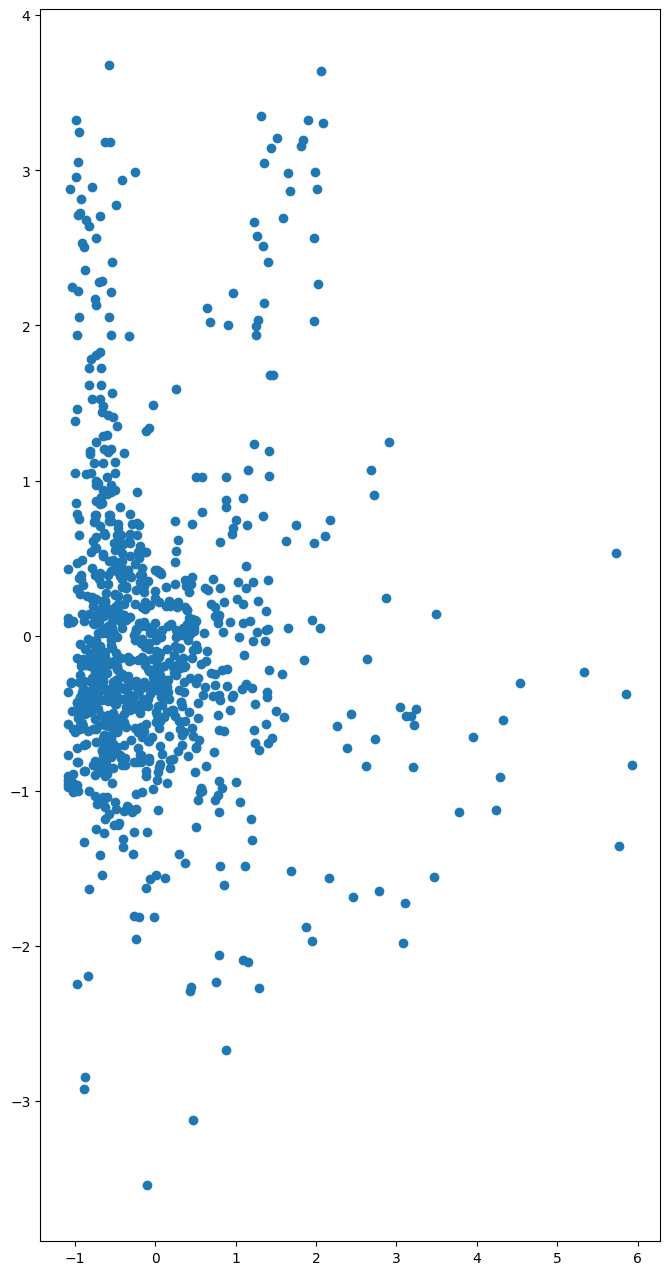

In [132]:
plt.figure(figsize=(8,16))

df_scaled = pd.DataFrame( StandardScaler().fit_transform(unemployement_in_india[['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)']]), columns=['Estimated Unemployment Rate (%)', 'Estimated Labour Participation Rate (%)'])

plt.scatter(df_scaled['Estimated Unemployment Rate (%)'], df_scaled['Estimated Labour Participation Rate (%)'])

<Axes: >

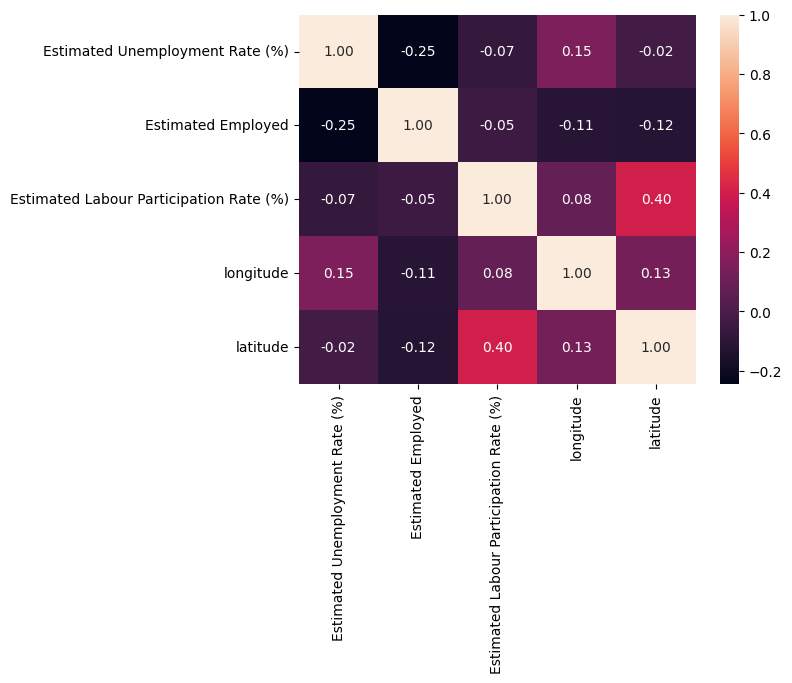

In [133]:
df_heatmap = df.drop(labels=['Region', 'Date', 'Location'], axis=1)

sns.heatmap(df_heatmap.corr(), annot=True, fmt='.2f')

### **Observations**

The correlation between Estimated Labour Participation Rate (LFPR) and latitude reflects indirect socioeconomic and climatic factors. Higher latitudes (further from the equator) typically correlate with higher overall LFPR due to more developed economies, longer life expectancies, and robust formal education systems that support higher female workforce involvement.

## **4.3 Urban vs Rural Unemployment**

The average unemployment rate in Rural India from 2019/05 to 2020/06 is 10.38%
The average unemployment rate in Urban India from 2019/05 to 2020/06 is 13.28%


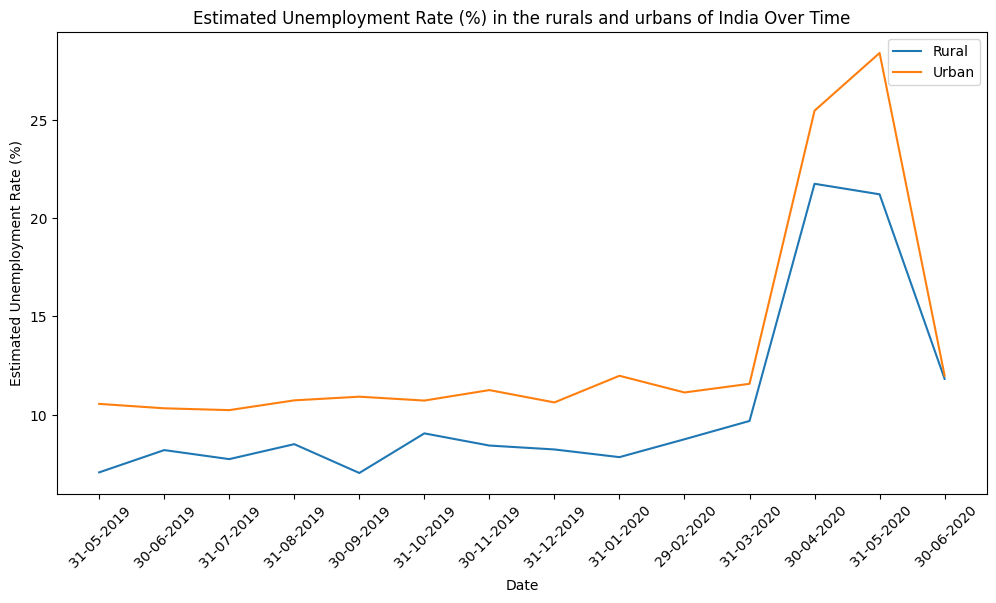

In [134]:
areas = df1['Area'].unique()
df1_dates = df1['Date'].unique()
#print(areas)

plt.figure(figsize=(12, 6))
for area in areas:
  y=[]
  x = df1[df1['Area']==area]

  for date in df1_dates:
    y.append(x[x['Date']==date]['Estimated Unemployment Rate (%)'].mean())

  plt.plot(x['Date'].unique(), y, label=area)
  print(f'The average unemployment rate in {area} India from 2019/05 to 2020/06 is {round(sum(y) / len(y), 2)}%')


plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in the rurals and urbans of India Over Time')

plt.legend()
plt.show()




### **Observations & Interpretation**

*   The urbans of india has a higher unempolyment rate then the rurals by 2.90%

*   The defrence btween the unemployment rate in the rurals and urbans of india stayies consistent with the time.

*   The unemolyment rate in the urbans has a sharper spike in the period of the pandamic


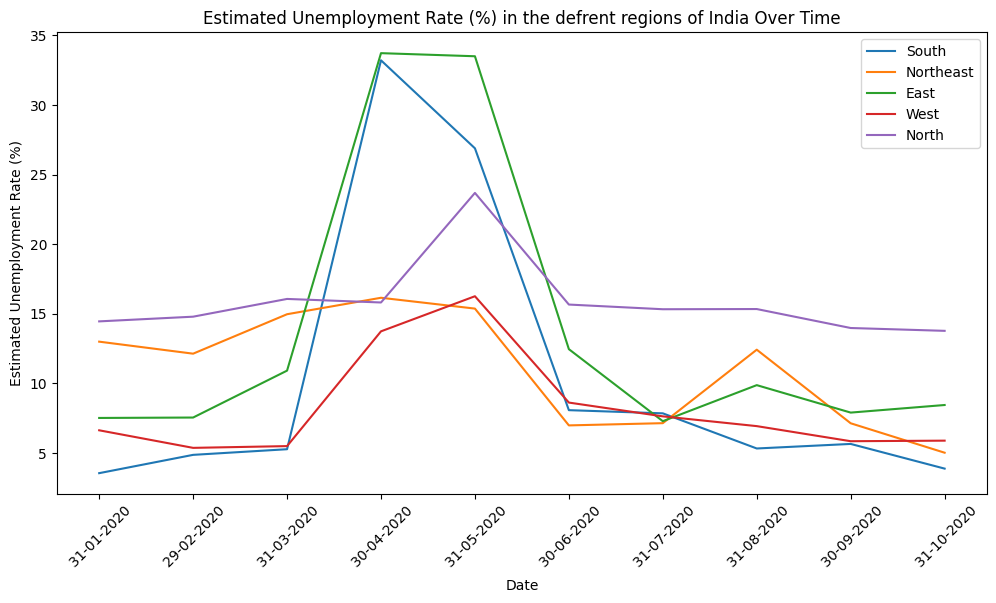

In [135]:
plt.figure(figsize=(12, 6))

df_dates = df['Date'].unique()
locations = df['Location'].unique()

for location in locations:
  y=[]
  x = df[df['Location']==location]

  for date in df_dates:
    y.append(x[x['Date']==date]['Estimated Unemployment Rate (%)'].mean())

  plt.plot(df_dates, y, label=location)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Unemployment Rate (%)')
plt.title('Estimated Unemployment Rate (%) in the defrent regions of India Over Time')

plt.legend()
plt.show()




### **Observations & Interpretation**

From the graph, we can see that the COVID-19 pandemic affected unemployment rates across all regions of India. The East and South experienced the sharpest increases, making them the most affected regions. The West saw a more gradual increase, while the North experienced a delayed and less severe rise in unemployment.

Most regions returned to their pre-pandemic unemployment levels after the pandemic. However, the Northeast did not fully return to its previous level, suggesting that long-term changes may have occurred in its labor market.

* **East and South:** Sharpest spikes in unemployment, indicating the strongest impact.
* **West:** A smoother and smaller increase in unemployment.
* **North:** A delayed and relatively moderate increase in unemployment.
* **Northeast:** Did not return to its pre-pandemic unemployment level, suggesting lasting changes in the regional labor market.

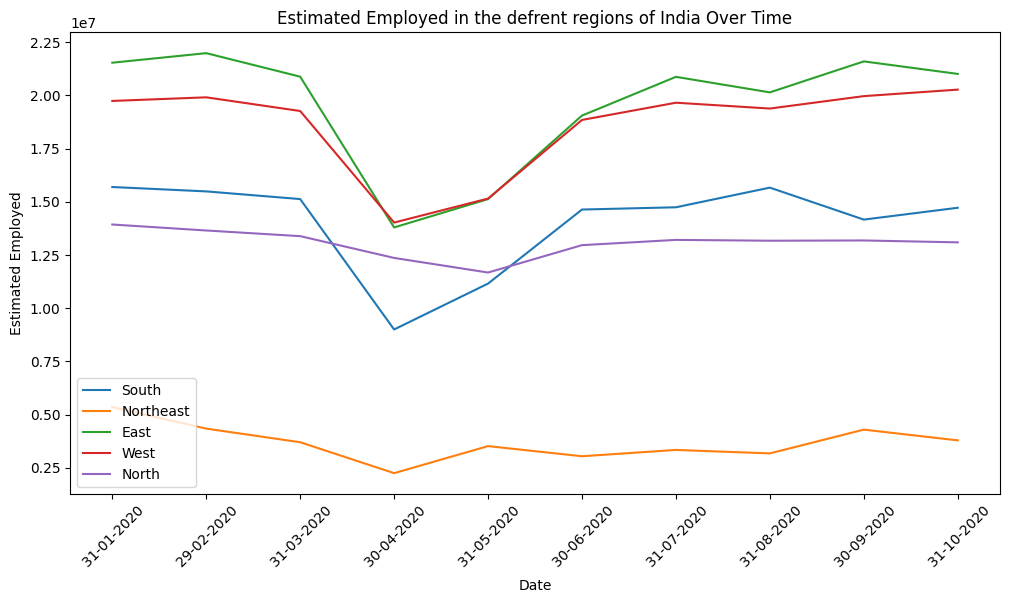

In [136]:
plt.figure(figsize=(12, 6))

df_dates = df['Date'].unique()
locations = df['Location'].unique()

for location in locations:
  y=[]
  x = df[df['Location']==location]

  for date in df_dates:
    y.append(x[x['Date']==date]['Estimated Employed'].mean())

  plt.plot(df_dates, y, label=location)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Employed')
plt.title('Estimated Employed in the defrent regions of India Over Time')

plt.legend()
plt.show()

the estimated employed number got back to the original number after the pandamic so the pandamic for all the regions that mean that it hadn't a longterm effect on it, also the effect of the pandamic in the estimated employed number in northeast was negligibel compared to the other regions.

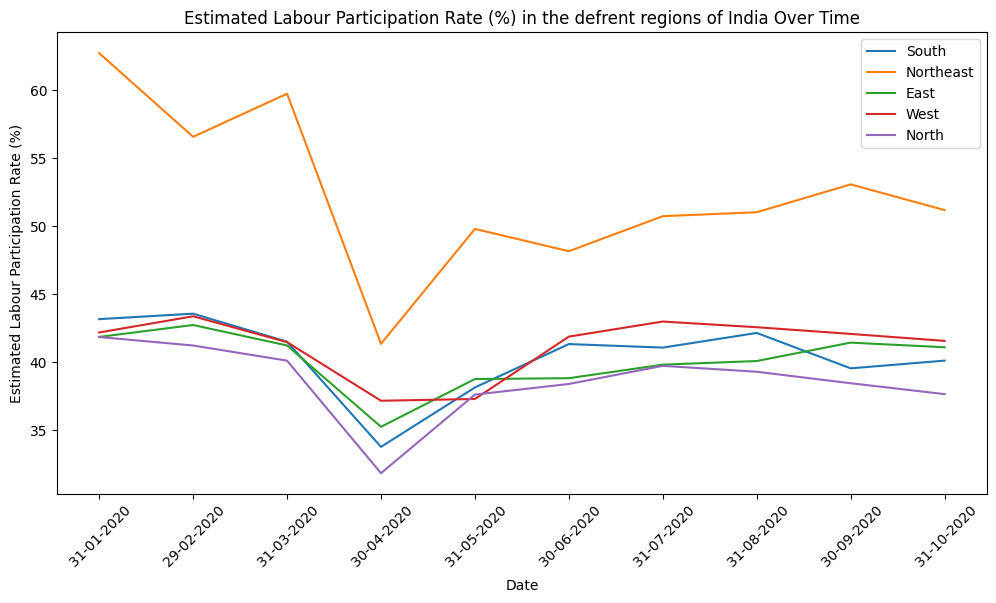

In [137]:
plt.figure(figsize=(12, 6))

df_dates = df['Date'].unique()
locations = df['Location'].unique()

for location in locations:
  y=[]
  x = df[df['Location']==location]

  for date in df_dates:
    y.append(x[x['Date']==date]['Estimated Labour Participation Rate (%)'].mean())

  plt.plot(df_dates, y, label=location)

plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Estimated Labour Participation Rate (%)')
plt.title('Estimated Labour Participation Rate (%) in the defrent regions of India Over Time')

plt.legend()
plt.show()

In the Northeast region, the unemployment rate decreased while the estimated number of employed people remained nearly unchanged, and the labour participation rate also declined. This suggests that the lower unemployment rate was not the result of new jobs being created. Instead, it is more likely that some people stopped looking for work and left the labour force, causing the unemployment rate to fall. Overall, this indicates a stagnant labour market rather than an improving economy.

In contrast, the pandemic had no clear long-term impact on the other regions. Their major labour market indicators eventually returned to their pre-pandemic levels, suggesting that the effects of COVID-19 were temporary.

# **5. Key Findings**

Example

- Maharashtra experienced one of the largest unemployment spikes.
    
- Urban unemployment remained consistently higher than rural unemployment.
    
- The national unemployment rate increased sharply during the COVID-19 lockdown.
    
- Most states returned to lower unemployment levels after the initial surge.

# **6. Conclusion**

This analysis explored unemployment trends across India during 2019–2020. The results show that unemployment increased dramatically during the COVID-19 lockdown, with considerable variation across states. Urban areas generally experienced higher unemployment than rural areas, highlighting the uneven economic impact of the pandemic.
